# Data Cleaning ,EDA and Feature Engineering
## 1. Loading Dataset and Overview of the data.
**Loads the data using Pandas Dataframe.**
It displays the number of rows and columns, previews the first few records, lists the column names, checks the data types, and produces descriptive statistics for the numerical columns.

**Checks for missing values, shows the date range covered by the dataset and counts duplicate rows.**
This first inspection is important because it helps confirm whether the dataset is complete, correctly structured and ready for cleaning and analysis.


In [ ]:
import pandas as pd

df=pd.read_csv("Data/Raw/BMW_Data.csv")

print("BMW Stock Data Analysis Summary:")
print("-----------------------------")
print("1. Data Overview:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.head())
print("\n2. Column Names:")
print(df.columns.tolist())
print("\n3. Data Types:")
print(df.dtypes)
print("\n4. Descriptive Statistics:")
print(df.describe())
print("\n5. Missing Values:")
print(df.isnull().sum())
print("\n6. Date Range:")
print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())
print("\n7.Duplicate rows:", df.duplicated().sum())


BMW Stock Data Analysis Summary:
-----------------------------
1. Data Overview:
Rows: 7212
Columns: 7
         Date  Adj_Close      Close       High        Low       Open   Volume
0   11/8/1996   8.100290  18.171000  18.209999  18.171000  18.209999   767000
1  11/11/1996   8.078445  18.122000  18.200001  18.082001  18.190001   260000
2  11/12/1996   8.139520  18.259001  18.327999  18.091999  18.160999  1066000
3  11/13/1996   8.126592  18.230000  18.344000  18.190001  18.344000   793000
4  11/14/1996   8.152893  18.289000  18.289000  18.132000  18.205000   351000

2. Column Names:
['Date', 'Adj_Close', 'Close', 'High', 'Low', 'Open', 'Volume']

3. Data Types:
Date             str
Adj_Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

4. Descriptive Statistics:
         Adj_Close        Close         High          Low         Open  \
count  7212.000000  7212.000000  7212.000000  7212.000000  7212.0000

## 2. Data Cleaning
### 1. Convert 'Date' column to datetime format
**Prepares the date column for time series analysis.**
The `Date` column is converted from text into a proper datetime format, which allows Python to sort the records chronologically and perform date-based operations later.
|
After converting the dates, the dataset is sorted from earliest to latest and the date is set as the index. 
*This makes the dataset easier to work with when plotting stock prices over time, calculating rolling averages, and resampling the data by year.*

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df = df.sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)
df.head()

,Adj_Close,Close,High,Low,Open,Volume
Date,,,,,,
1996-11-08,8.100290,18.171000,18.209999,18.171000,18.209999,767000
1996-11-11,8.078445,18.122000,18.200001,18.082001,18.190001,260000
1996-11-12,8.139520,18.259001,18.327999,18.091999,18.160999,1066000
1996-11-13,8.126592,18.230000,18.344000,18.190001,18.344000,793000
1996-11-14,8.152893,18.289000,18.289000,18.132000,18.205000,351000


### 2.Check for OHLC inconsistencies
**Checks whether the Open, High, Low, and Close price values follow logical stock market rules.** 
- For example, the low price should not be greater than the high price, and the open and close prices should fall between the low and high prices for that trading day.

Any rows that break these rules are identified as *inconsistent*. 
A new column called `OHLC_flag` is then created to mark inconsistent rows with a value of 1 and valid rows with a value of 0. 
*This allows the analysis to exclude suspicious records while still keeping track of where data quality issues occurred.*


In [61]:
# Check for OHLC inconsistencies
inconsistent = df[(df['Low'] > df['High']) |
                   (df['Open'] > df['High']) | (df['Open'] < df['Low']) |
                   (df['Close'] > df['High']) | (df['Close'] < df['Low'])]
print('Rows with OHLC inconsistencies:', len(inconsistent))

#Flagging Inconsistencies
df['OHLC_flag'] = 0
df.loc[inconsistent.index, 'OHLC_flag'] = 1
inconsistent.head()


Rows with OHLC inconsistencies: 147


,Adj_Close,Close,High,Low,Open,Volume
Date,,,,,,
1997-05-02,12.917848,28.978001,29.045000,28.731001,28.377001,416000
1997-05-23,12.579498,28.219000,28.259001,28.101000,27.138000,91000
1997-05-28,12.518430,28.082001,28.636999,27.826000,29.537001,572000
1997-06-05,12.553203,28.160000,28.219000,28.091999,27.826000,231400
1997-07-07,12.944593,29.038000,29.246000,28.927000,28.908001,210600


### 3. Univariate Analysis of Stock Prices
**Performs univariate analysis, which means it studies one variable at a time.** 
The code first removes rows that were flagged as inconsistent, creating a cleaner dataset for analysis.

Histograms are then used to show the distributions of the Close, High, Low, and Open prices.
These plots help reveal the general price range, common values, and any unusual patterns in the data. 
A line plot is also created to show how the four main price variables move over time.

*Together, these visualizations provide a first look at the behavior of BMW stock prices across the full time period.*


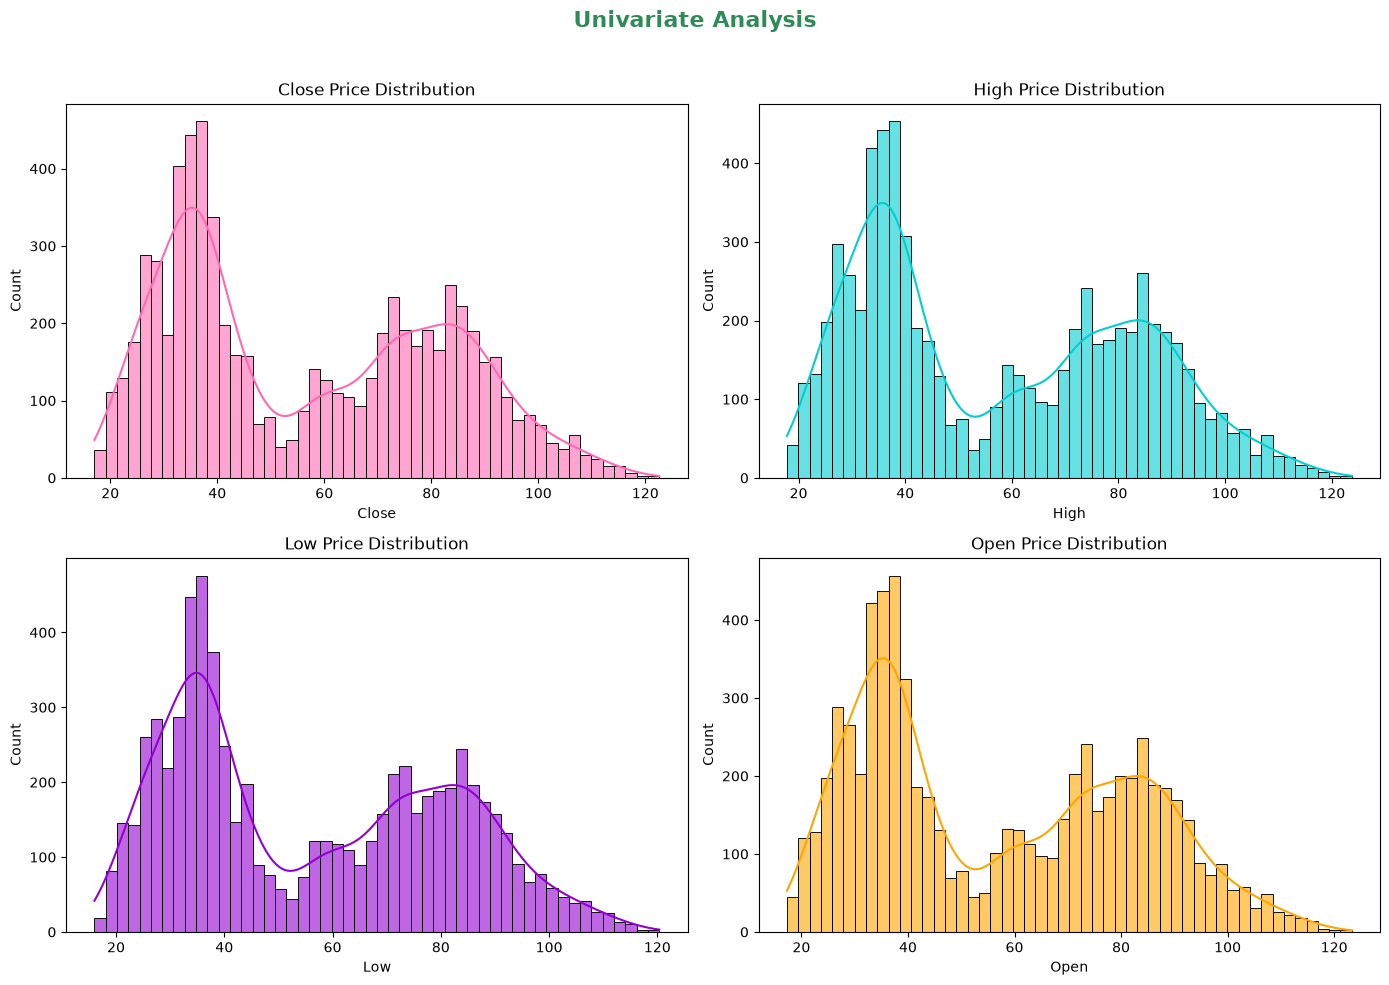

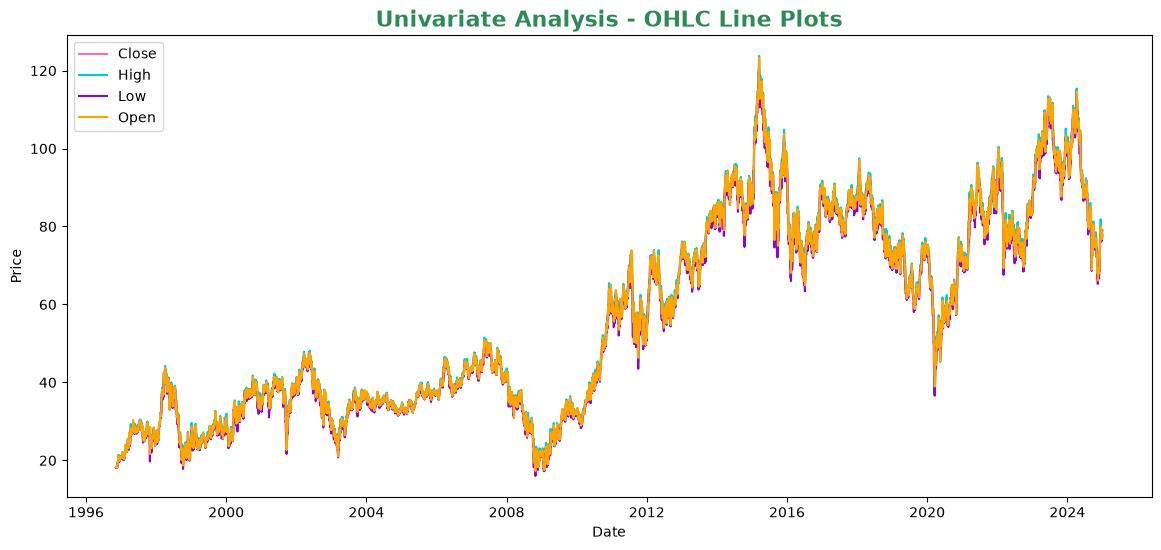

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use cleaned dataset (no flagged inconsistencies)
df_clean = df[df['OHLC_flag'] == 0]

# 2x2 grid for histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of Close
sns.histplot(df_clean['Close'], bins=50, kde=True, ax=axes[0,0], color="#FF69B4", alpha=0.6)
axes[0,0].set_title('Close Price Distribution')

# Histogram of High
sns.histplot(df_clean['High'], bins=50, kde=True, ax=axes[0,1], color="#00CED1", alpha=0.6)
axes[0,1].set_title('High Price Distribution')

# Histogram of Low
sns.histplot(df_clean['Low'], bins=50, kde=True, ax=axes[1,0], color="#9400D3", alpha=0.6)
axes[1,0].set_title('Low Price Distribution')

# Histogram of Open
sns.histplot(df_clean['Open'], bins=50, kde=True, ax=axes[1,1], color="#FFA500", alpha=0.6)
axes[1,1].set_title('Open Price Distribution')

# Super title for the whole layout
fig.suptitle("Univariate Analysis", fontsize=16, color="#2E8B57", weight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Space for super title
plt.show()

# Line plots for OHLC
plt.figure(figsize=(14,6))
plt.plot(df_clean.index, df_clean['Close'], label='Close', color="#FF69B4")
plt.plot(df_clean.index, df_clean['High'], label='High', color="#00CED1")
plt.plot(df_clean.index, df_clean['Low'], label='Low', color="#9400D3")
plt.plot(df_clean.index, df_clean['Open'], label='Open', color="#FFA500")
plt.title("Univariate Analysis - OHLC Line Plots", fontsize=16, color="#2E8B57", weight="bold")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


### 4. Bivariate Analysis
**Compares pairs of variables to understand how they relate to each other.** 
The Open and Close prices are compared using a scatter plot with a trend line to see whether the opening price is strongly related to the closing price.

- The Adjusted Close and Close prices are plotted over time to check how closely they move together. 
- The relationship between Close price and Volume is also explored, with volume shown on a log scale because trading volume can vary widely. 
- Finally, High and Low prices are compared, and their correlation coefficient is displayed to measure the strength of their relationship.

*This analysis helps identify relationships between important stock market variables before moving into modelling.*


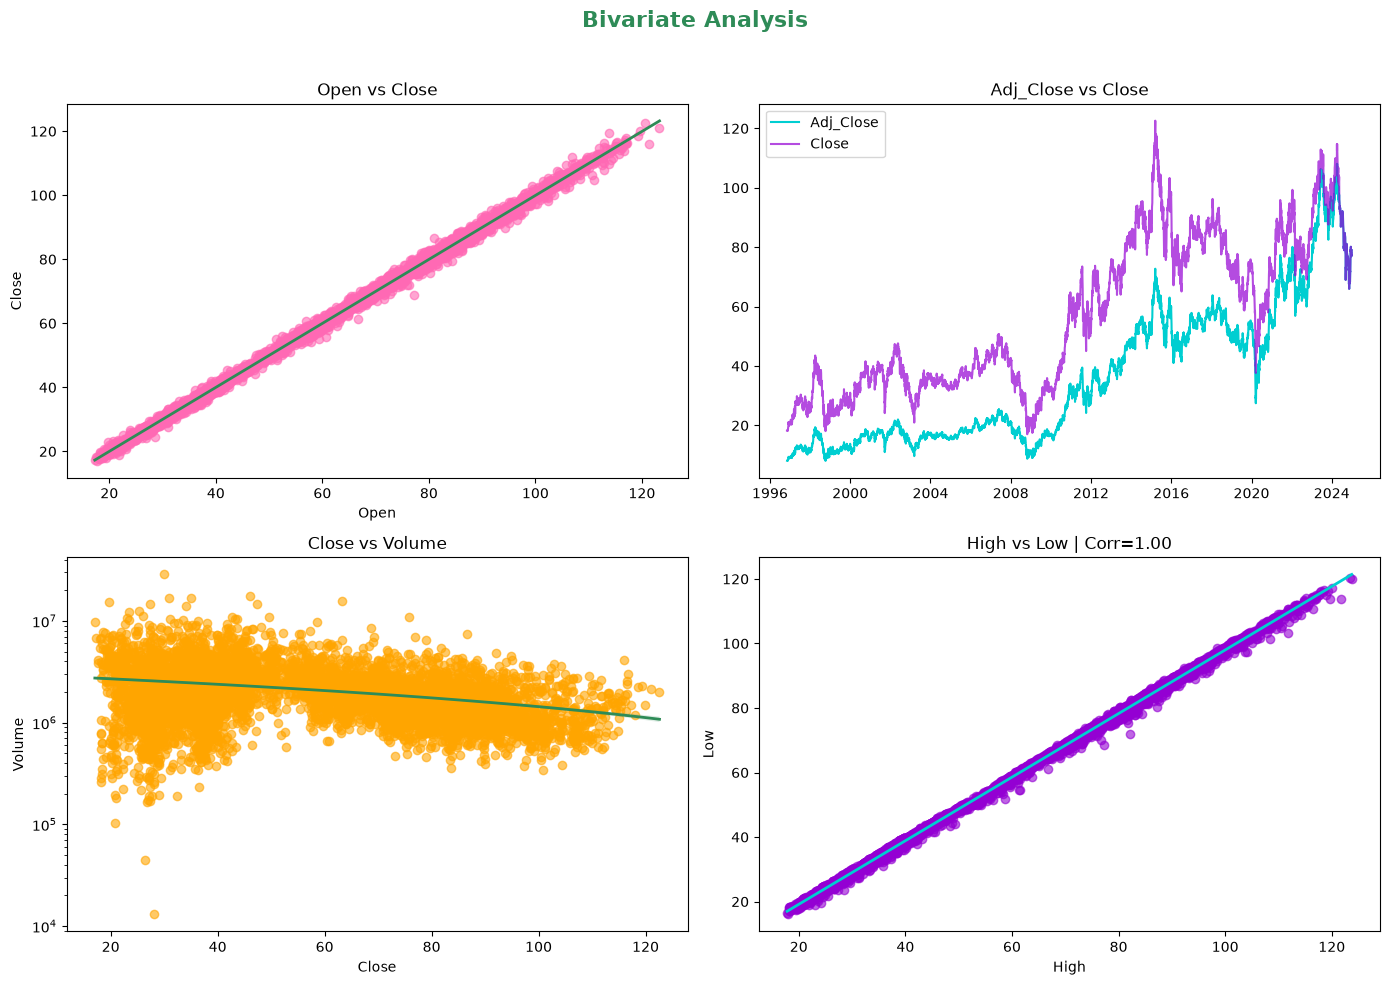

In [63]:
#Bivariate Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Open vs Close → Scatter plot with Trend Line
sns.regplot(x=df_clean['Open'], y=df_clean['Close'], ax=axes[0,0],
            scatter_kws={'color':"#FF69B4", 'alpha':0.6},
            line_kws={'color':"#2E8B57", 'linewidth':2})
axes[0,0].set_title("Open vs Close")

# 2. Adj_Close vs Close → Line plot
axes[0,1].plot(df_clean.index, df_clean['Adj_Close'], label='Adj_Close', color="#00CED1")
axes[0,1].plot(df_clean.index, df_clean['Close'], label='Close', color="#9400D3", alpha=0.7)
axes[0,1].set_title("Adj_Close vs Close")
axes[0,1].legend()

# 3. Close vs Volume → Scatter plot with log scale and Trend Line
sns.regplot(x=df_clean['Close'], y=df_clean['Volume'], ax=axes[1,0],
            scatter_kws={'color':"#FFA500", 'alpha':0.6},
            line_kws={'color':"#2E8B57", 'linewidth':2})
axes[1,0].set_title("Close vs Volume")
axes[1,0].set_yscale("log")

# 4. High vs Low → Correlation coefficient + scatter with Trend Line
sns.regplot(x=df_clean['High'], y=df_clean['Low'], ax=axes[1,1],
            scatter_kws={'color':"#9400D3", 'alpha':0.6},
            line_kws={'color':"#00CED1", 'linewidth':2})
corr = df_clean[['High','Low']].corr().iloc[0,1]
axes[1,1].set_title(f"High vs Low | Corr={corr:.2f}")

# Super title
fig.suptitle("Bivariate Analysis", fontsize=16, color="#2E8B57", weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### 5.Multivariate Analysis
**Examines relationships among multiple numerical variables at the same time.**
- A correlation heatmap is created for Open, High, Low, Close, Adjusted Close, and Volume. 
The heatmap shows how strongly each pair of variables is related.

- A pairplot is also created to display scatter plots and distributions for the same variables. 
This gives a broader view of how the stock price variables interact with one another and whether any variables show strong patterns, clusters, or outliers.

*Multivariate analysis is useful because machine learning models often depend on relationships between several features, not just one variable at a time.*


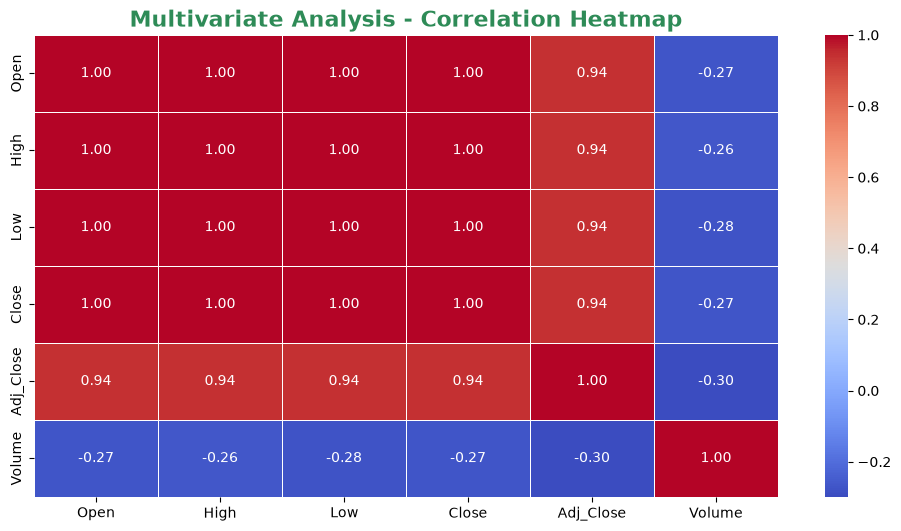

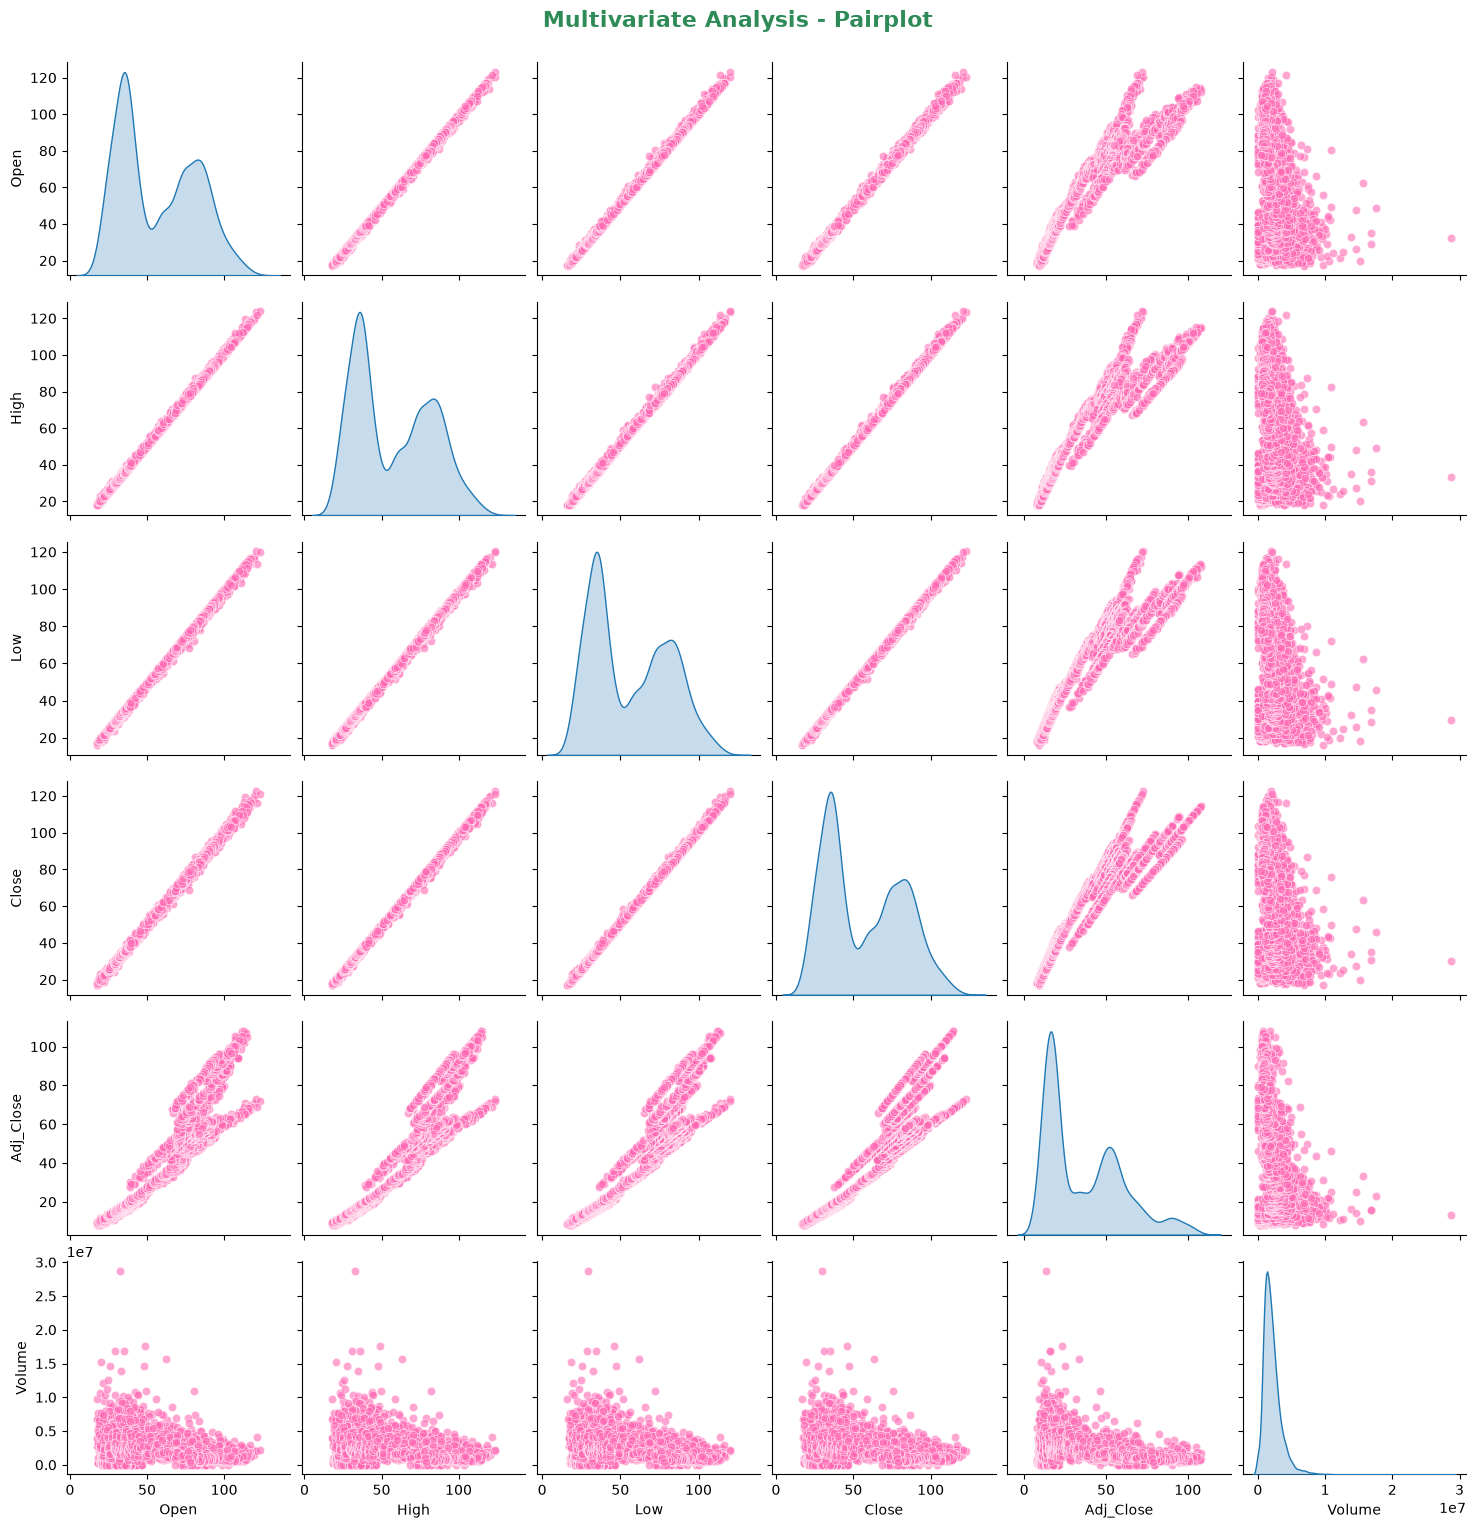

In [64]:
#Multivariate Analysis

# --- Correlation Heatmap ---
plt.figure(figsize=(12, 6))
corr_matrix = df_clean[['Open','High','Low','Close','Adj_Close','Volume']].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Multivariate Analysis - Correlation Heatmap", fontsize=16, color="#2E8B57", weight="bold")
plt.show()

# --- Pairplot ---
pair = sns.pairplot(df_clean[['Open','High','Low','Close','Adj_Close','Volume']],
                    diag_kind="kde",
                    plot_kws={'alpha':0.6, 'color':"#FF69B4"})
pair.fig.suptitle("Multivariate Analysis - Pairplot", fontsize=16, color="#2E8B57", weight="bold", y=1.02)
plt.show()


### 6. Time Series
**How BMW's closing price changes over time.**
- The first plot shows the daily closing price across the full dataset, making it easier to observe long-term trends, increases, decreases, and periods of volatility.

- The second plot calculates the average closing price for each year and displays it as a bar chart. 
This yearly summary makes it easier to compare stock performance across different years without focusing on daily fluctuations.

*This step is important because stock data is time-based, and the order of observations matters when interpreting market behavior.*


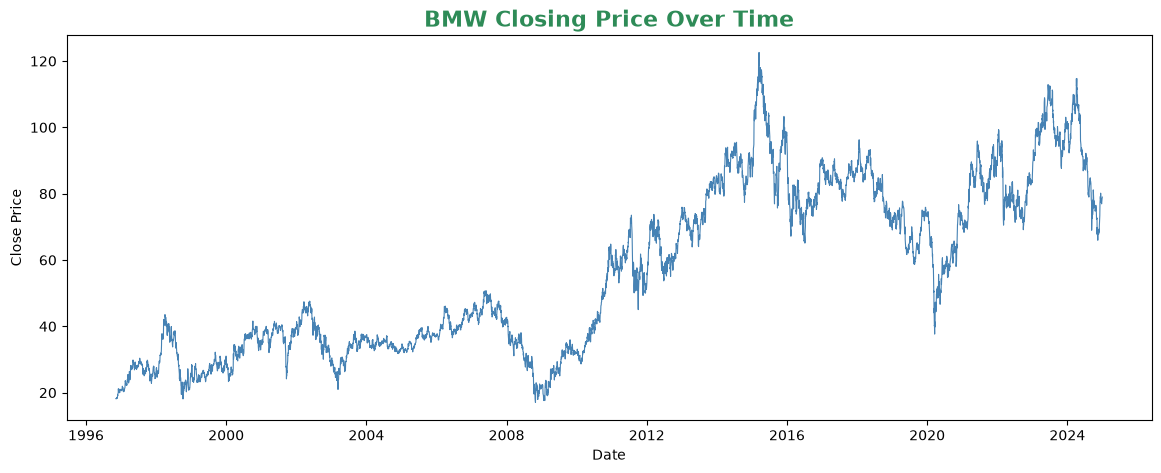

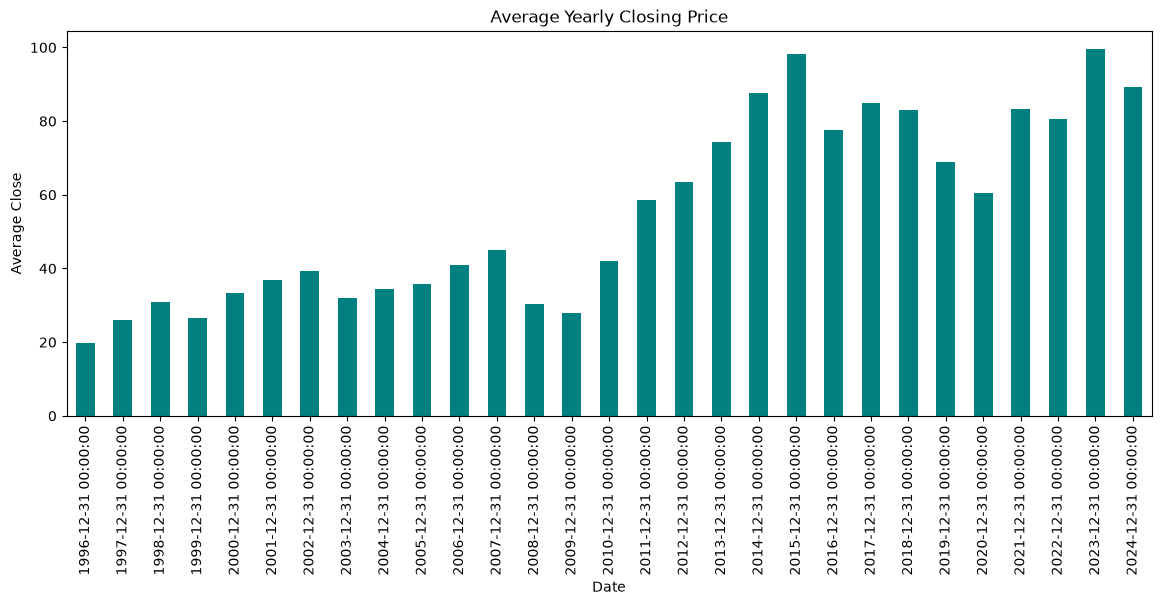

In [65]:
#Time Series
# Plot Closing Price over time
plt.figure(figsize=(14,5))
plt.plot(df_clean.index, df_clean['Close'], color='steelblue', linewidth=0.8)
plt.title('BMW Closing Price Over Time', fontsize=16, color="#2E8B57", weight="bold")
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

#Yearly Average
yearly_avg = df_clean['Close'].resample('YE').mean()
plt.figure(figsize=(14,5))
yearly_avg.plot(kind='bar', color='teal')
plt.title('Average Yearly Closing Price')
plt.ylabel('Average Close')
plt.xticks(rotation=90)
plt.show()


## 2. Feature Engineering  
### 1. Feature Engineering and Saving the Clean Dataset

**Creates new features that provide additional information for later analysis and modelling.** 
- `Daily_Return` measures the percentage change in closing price from one day to the next. 
- `Price_Range` measures the difference between the high and low prices. 
- `Open_Close_Diff` shows how much the price changed between market open and close. 
- `Volume_Change` measures the percentage change in trading volume.

Because percentage-change calculations create missing values at the beginning of the dataset, the code checks for missing values and fills missing engineered values with 0. 
inally, the cleaned and enhanced dataset is saved as a CSV file so it can be used in the modelling notebook.


In [ ]:
# Feature Engineering
# Daily Return
df_clean["Daily_Return"] = df_clean["Close"].pct_change()

# Price Range
df_clean["Price_Range"] = df_clean["High"] - df_clean["Low"]

# Open‑Close Difference
df_clean["Open_Close_Diff"] = df_clean["Close"] - df_clean["Open"]

# Volume Change
df_clean["Volume_Change"] = df_clean["Volume"].pct_change()

#Check for NaN values
print("NaN Values Per Column\n",df_clean.isna().sum())

# Replace NaNs in engineered columns with 0
engineered_cols = ["Daily_Return","Price_Range","Open_Close_Diff","Volume_Change"]
df_clean[engineered_cols] = df_clean[engineered_cols].fillna(0)

# Confirm replacement
print("NaN Values Per Column After Handling\n", df_clean.isna().sum())

print(df_clean.head())

# Save DataSet
# Save final dataset as CSV
df_clean.to_csv("Data/Clean/Final_BMW_dataset.csv", index=True)


NaN Values Per Column
 Adj_Close           0
Close               0
High                0
Low                 0
Open                0
Volume              0
OHLC_flag           0
Daily_Return        1
Price_Range         0
Open_Close_Diff     0
Volume_Change      41
dtype: int64
NaN Values Per Column After Handling
 Adj_Close          0
Close              0
High               0
Low                0
Open               0
Volume             0
OHLC_flag          0
Daily_Return       0
Price_Range        0
Open_Close_Diff    0
Volume_Change      0
dtype: int64
            Adj_Close      Close       High        Low       Open   Volume  \
Date                                                                         
1996-11-08   8.100290  18.171000  18.209999  18.171000  18.209999   767000   
1996-11-11   8.078445  18.122000  18.200001  18.082001  18.190001   260000   
1996-11-12   8.139520  18.259001  18.327999  18.091999  18.160999  1066000   
1996-11-13   8.126592  18.230000  18.344000  18.19

### 2. Moving Average Analysis

**Reload the cleaned dataset and calculates two moving averages:**
A 50-day moving average and a 200-day moving average. 
*Moving averages smooth out short-term price fluctuations and make it easier to identify longer-term trends*

The closing price is plotted together with the two moving averages.
 The 50-day moving average reflects shorter-term movement, while the 200-day moving average reflects the broader long-term trend. Comparing these lines can help identify possible trend changes in the stock price.


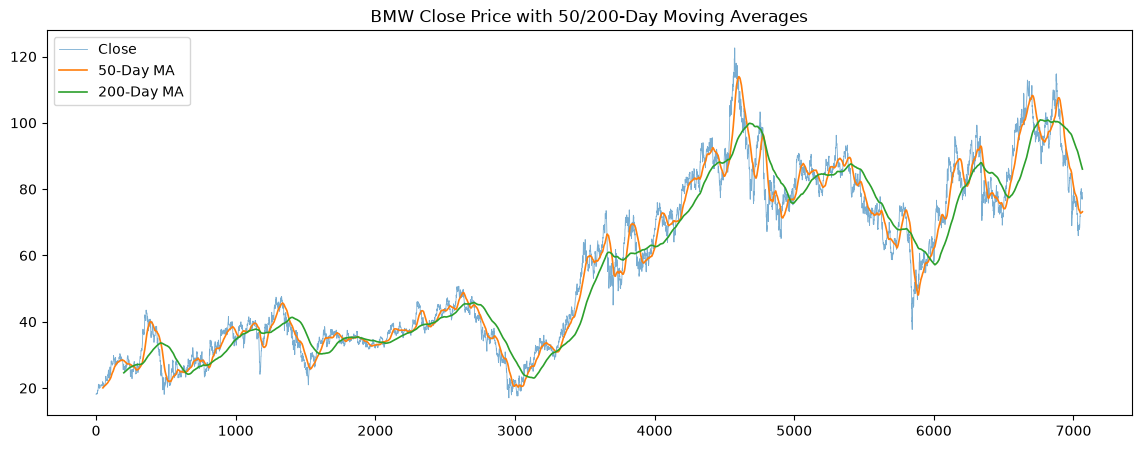

In [ ]:
import pandas as pd
import matplotlib.pyplot  as plt

# Moving Averages
df=pd.read_csv("Data/Clean/Final_BMW_dataset.csv")
df['MA_50'] = df['Close'].rolling(50).mean()
df['MA_200'] = df['Close'].rolling(200).mean()

plt.figure(figsize=(14,5))
plt.plot(df.index, df['Close'], label='Close', linewidth=0.6, alpha=0.6)
plt.plot(df.index, df['MA_50'], label='50-Day MA', linewidth=1.2)
plt.plot(df.index, df['MA_200'], label='200-Day MA', linewidth=1.2)
plt.title('BMW Close Price with 50/200-Day Moving Averages')
plt.legend()
plt.show()

### 3. Rolling Volatility Analysis

**Calculates 30-day rolling volatility using the standard deviation of daily returns.**
*Volatility measures how much the stock's returns fluctuate over time, which is an important indicator of risk.*

The resulting plot shows periods when BMW stock returns were more stable and periods when they were more variable. 
The cell also checks for missing values after calculating volatility, since rolling calculations naturally create missing values at the beginning of the series.


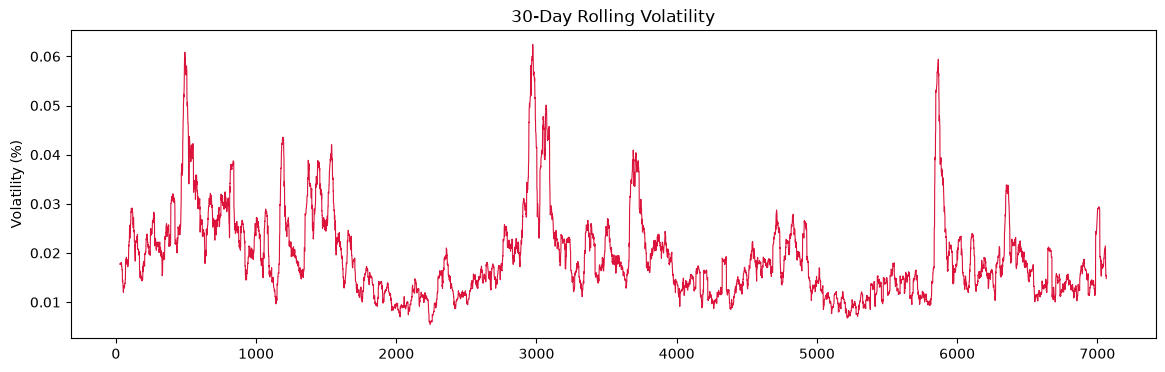

NaN Values Per Column
 Date                 0
Adj_Close            0
Close                0
High                 0
Low                  0
Open                 0
Volume               0
OHLC_flag            0
Daily_Return         0
Price_Range          0
Open_Close_Diff      0
Volume_Change        0
MA_50               49
MA_200             199
Volatility_30d      29
dtype: int64


In [11]:
# Volatility
df['Volatility_30d'] = df['Daily_Return'].rolling(30).std()
plt.figure(figsize=(14,4))
plt.plot(df.index, df['Volatility_30d'], color='crimson', linewidth=0.8)
plt.title('30-Day Rolling Volatility')
plt.ylabel('Volatility (%)')
plt.show()

print("NaN Values Per Column\n",df.isna().sum())

